In [2]:
import pandas as pd
import os

possible_paths = [
    r'C:\Users\bobir\OneDrive\Desktop\cleaned_cars_2025.csv',
    r'C:\Users\bobir\Desktop\cleaned_cars_2025.csv',
    'cleaned_cars_2025.csv'
]

file_path = next((p for p in possible_paths if os.path.exists(p)), None)

if not file_path:
    raise FileNotFoundError("Файл cleaned_cars_2025.csv не найден")

df = pd.read_csv(file_path)

df['Cost_per_HP'] = (df['Price_USD'] / df['HorsePower_HP']).round(2)

fuel_summary = df.groupby('Fuel_Category').agg(
    Avg_Price=('Price_USD', 'mean'),
    Avg_HP=('HorsePower_HP', 'mean'),
    Avg_Cost_per_HP=('Cost_per_HP', 'mean'),
    Car_Count=('Cars Names', 'count')
).round(2).reset_index()

print("=== СРАВНЕНИЕ ПО ТИПАМ ДВИГАТЕЛЯ ===")
print(fuel_summary)

=== СРАВНЕНИЕ ПО ТИПАМ ДВИГАТЕЛЯ ===
   Fuel_Category  Avg_Price  Avg_HP  Avg_Cost_per_HP  Car_Count
0         Diesel   41439.65  222.74           207.50        129
1       Electric   67780.15  393.24           190.98         98
2  Hybrid / PHEV  131670.20  304.55           284.11        114
3          Other   46633.33  154.67           302.90          3
4         Petrol  161309.12  311.20           282.76        874


In [3]:
ev_df = df[df['Fuel_Category'].astype(str).str.contains('Electric|EV|Hybrid', case=False, na=False)].copy()

top_value_ev = ev_df.sort_values(by='Cost_per_HP').head(10)
top_overpriced_ev = ev_df.sort_values(by='Cost_per_HP', ascending=False).head(10)

print("\n=== ТОП-10 САМЫХ ВЫГОДНЫХ EV/HYBRID ($ ЗА 1 Л.С.) ===")
print(top_value_ev[['Company Names', 'Cars Names', 'Price_USD', 'HorsePower_HP', 'Cost_per_HP']])

print("\n=== ТОП-10 САМЫХ ПЕРЕОЦЕНЕННЫХ EV/HYBRID ($ ЗА 1 Л.С.) ===")
print(top_overpriced_ev[['Company Names', 'Cars Names', 'Price_USD', 'HorsePower_HP', 'Cost_per_HP']])

df.to_csv('cars_efficiency_2025.csv', index=False)


=== ТОП-10 САМЫХ ВЫГОДНЫХ EV/HYBRID ($ ЗА 1 Л.С.) ===
     Company Names                  Cars Names  Price_USD  HorsePower_HP  \
667          Tesla                  Cybertruck    69900.0          800.0   
199         TOYOTA                       CAMRY    27000.0          301.0   
796            GMC  Hummer EV Pickup Edition 1    96550.0         1000.0   
660          Tesla               Model S Plaid   108490.0         1020.0   
664          Tesla               Model X Plaid   113490.0         1020.0   
854            Kia          EV6 GT Performance    65000.0          577.0   
812            GMC     Hummer EV Omega Edition   112700.0         1000.0   
1060          Ford     Explorer Plug-in Hybrid    53000.0          457.0   
795            GMC     Hummer EV SUV Edition 1    96550.0          830.0   
1029          Ford                    Maverick    26000.0          220.5   

      Cost_per_HP  
667         87.38  
199         89.70  
796         96.55  
660        106.36  
664     

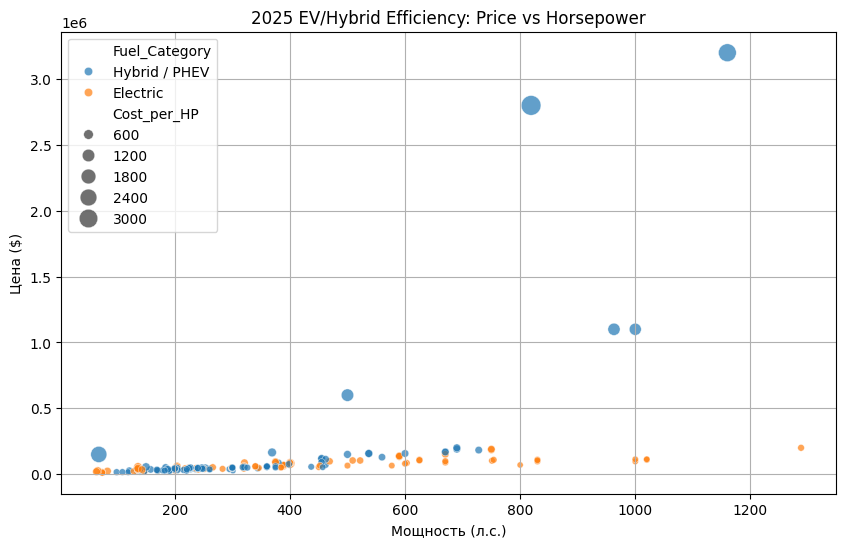

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = ev_df.dropna(subset=['HorsePower_HP', 'Price_USD', 'Cost_per_HP']).copy()
plot_df = plot_df[plot_df['Cost_per_HP'] > 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x='HorsePower_HP',
    y='Price_USD',
    hue='Fuel_Category',
    size='Cost_per_HP',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('2025 EV/Hybrid Efficiency: Price vs Horsepower')
plt.xlabel('Мощность (л.с.)')
plt.ylabel('Цена ($)')
plt.grid(True)
plt.show()